# CNN Regularization using CIFAR-10 dataset

<center>
  <h1>Programme: Master of Science in Artificial Intelligence</h1>
  <h1>Course: CSA 809 Deep Learning</h1>
  <h2>Name: Marrion Kiprop Cherop</h2>
  <h3>Reg Number: ST62/80971/2024</h3>
  <h3>Module 8: Regularization in Cnns</h3>
</center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

## 1. Load and Preprocess CIFAR-10 Dataset

In [4]:
import os
import tarfile
import pickle
import numpy as np
import shutil # Import shutil for rmtree

# Define path to the uploaded tar.gz file
uploaded_tar_path = '/content/sample_data/cifar-10-python.tar.gz'
extracted_dir = '/tmp/cifar-10-batches-py'

# Ensure the parent directory for extraction exists
os.makedirs('/tmp', exist_ok=True)

# Force re-extraction: Remove the existing extracted directory if it exists
if os.path.exists(extracted_dir):
    print(f"Removing existing extracted directory: {extracted_dir}")
    shutil.rmtree(extracted_dir)

# Create extraction directory
os.makedirs(extracted_dir, exist_ok=True)

print(f"Extracting {uploaded_tar_path} to {extracted_dir}...")
with tarfile.open(uploaded_tar_path, 'r:gz') as tar:
    # The tar file contains a directory 'cifar-10-batches-py' at its root.
    # We want its contents directly in `extracted_dir`.
    # Extract to '/tmp' so that 'cifar-10-batches-py' is created directly under '/tmp'
    tar.extractall(path='/tmp')
print("Extraction complete.")


def unpickle(file_path):
    with open(file_path, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Load training data
x_train_list = []
y_train_list = []
for i in range(1, 6):
    batch_path = os.path.join(extracted_dir, f'data_batch_{i}')
    data_dict = unpickle(batch_path)
    x_train_list.append(data_dict[b'data'])
    y_train_list.append(data_dict[b'labels'])

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)

# Load test data
test_batch_path = os.path.join(extracted_dir, 'test_batch')
data_dict = unpickle(test_batch_path)
x_test = data_dict[b'data']
y_test = np.array(data_dict[b'labels'])

# Reshape images from (N, 3072) to (N, 32, 32, 3)
x_train = x_train.reshape((x_train.shape[0], 3, 32, 32)).transpose(0, 2, 3, 1)
x_test = x_test.reshape((x_test.shape[0], 3, 32, 32)).transpose(0, 2, 3, 1)

# Normalize image data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

Removing existing extracted directory: /tmp/cifar-10-batches-py
Extracting /content/sample_data/cifar-10-python.tar.gz to /tmp/cifar-10-batches-py...


/tmp/ipykernel_1057/1048871513.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/tmp')


Extraction complete.


In [5]:
# Display dataset shapes to confirm preprocessing
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


## 2. CNN Model with No Regularization

In [6]:
def create_no_regularization_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_no_reg = create_no_regularization_cnn()
model_no_reg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_no_reg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_no_reg = model_no_reg.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4388 - loss: 1.5368 - val_accuracy: 0.5206 - val_loss: 1.3801
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5909 - loss: 1.1631 - val_accuracy: 0.6023 - val_loss: 1.1267
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6469 - loss: 1.0076 - val_accuracy: 0.6486 - val_loss: 1.0049
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6902 - loss: 0.8871 - val_accuracy: 0.6767 - val_loss: 0.9330
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7186 - loss: 0.8039 - val_accuracy: 0.6982 - val_loss: 0.8760
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7437 - loss: 0.7380 - val_accuracy: 0.6943 - val_loss: 0.8971
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7661 - loss: 0.6756 - val_accuracy: 0.7020 - val_loss: 0.8650
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7824 - loss: 0.6241 - val_accuracy: 0

In [8]:
# Evaluate the model
loss_no_reg, accuracy_no_reg = model_no_reg.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss (No Regularization): {loss_no_reg:.4f}")
print(f"Test Accuracy (No Regularization): {accuracy_no_reg:.4f}")

Test Loss (No Regularization): 1.2826
Test Accuracy (No Regularization): 0.7010


## 3. CNN Model with Dropout Only

In [9]:
def create_dropout_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Dropout(0.25), # Dropout layer
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25), # Dropout layer
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Dropout layer
        Dense(num_classes, activation='softmax')
    ])
    return model

model_dropout = create_dropout_cnn()
model_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_dropout = model_dropout.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3406 - loss: 1.7719 - val_accuracy: 0.4976 - val_loss: 1.3910
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4955 - loss: 1.4034 - val_accuracy: 0.5862 - val_loss: 1.1960
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5535 - loss: 1.2641 - val_accuracy: 0.6175 - val_loss: 1.1027
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5861 - loss: 1.1762 - val_accuracy: 0.6361 - val_loss: 1.0329
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6125 - loss: 1.1021 - val_accuracy: 0.6634 - val_loss: 0.9529
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6372 - loss: 1.0446 - val_accuracy: 0.6725 - val_loss: 0.9433
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6506 - loss: 1.0026 - val_accuracy: 0.6828 - val_loss: 0.9239
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6664 - loss: 0.9638 - val_accuracy: 

In [11]:
# Evaluate the model
loss_dropout, accuracy_dropout = model_dropout.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss (Dropout Only): {loss_dropout:.4f}")
print(f"Test Accuracy (Dropout Only): {accuracy_dropout:.4f}")

Test Loss (Dropout Only): 0.7378
Test Accuracy (Dropout Only): 0.7507


## 4. CNN Model with L2 Regularization Only

In [12]:
def create_l2_cnn(input_shape=(32, 32, 3), num_classes=10, l2_lambda=0.0001):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(l2_lambda)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(l2_lambda)),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(l2_lambda)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_l2 = create_l2_cnn()
model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_l2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_l2 = model_l2.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4133 - loss: 1.6181 - val_accuracy: 0.5335 - val_loss: 1.3209
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5681 - loss: 1.2462 - val_accuracy: 0.5903 - val_loss: 1.1811
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6294 - loss: 1.0890 - val_accuracy: 0.6370 - val_loss: 1.0779
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6698 - loss: 0.9881 - val_accuracy: 0.6649 - val_loss: 1.0070
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6979 - loss: 0.9112 - val_accuracy: 0.6895 - val_loss: 0.9587
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7212 - loss: 0.8456 - val_accuracy: 0.6950 - val_loss: 0.9440
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7375 - loss: 0.8060 - val_accuracy: 0.7106 - val_loss: 0.9052
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7573 - loss: 0.7528 - val_accuracy: 

In [14]:
# Evaluate the model
loss_l2, accuracy_l2 = model_l2.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss (L2 Regularization Only): {loss_l2:.4f}")
print(f"Test Accuracy (L2 Regularization Only): {accuracy_l2:.4f}")

Test Loss (L2 Regularization Only): 1.0471
Test Accuracy (L2 Regularization Only): 0.7253


## 5. CNN Model with Dropout + L2 + Early Stopping

In [15]:
def create_all_reg_cnn(input_shape=(32, 32, 3), num_classes=10, l2_lambda=0.0001, dropout_rate=0.25):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(l2_lambda)),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(l2_lambda)),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate),
        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(l2_lambda)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_all_reg = create_all_reg_cnn()
model_all_reg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_all_reg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_all_reg = model_all_reg.fit(
    x_train, y_train,
    epochs=50, # Using more epochs as early stopping will stop training when performance stagnates
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.3566 - loss: 1.7633 - val_accuracy: 0.5077 - val_loss: 1.3998
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5084 - loss: 1.4144 - val_accuracy: 0.5541 - val_loss: 1.2885
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5559 - loss: 1.2987 - val_accuracy: 0.5997 - val_loss: 1.1853
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5921 - loss: 1.2127 - val_accuracy: 0.6419 - val_loss: 1.0753
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6188 - loss: 1.1534 - val_accuracy: 0.6613 - val_loss: 1.0315
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6347 - loss: 1.1122 - val_accuracy: 0.6650 - val_loss: 1.0271
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6518 - loss: 1.0705 - val_accuracy: 0.6646 - val_loss: 1.0119
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6665 - loss: 1.0409 - val_accuracy: 

In [17]:
# Evaluate the model
loss_all_reg, accuracy_all_reg = model_all_reg.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss (Dropout + L2 + Early Stopping): {loss_all_reg:.4f}")
print(f"Test Accuracy (Dropout + L2 + Early Stopping): {accuracy_all_reg:.4f}")

Test Loss (Dropout + L2 + Early Stopping): 0.8035
Test Accuracy (Dropout + L2 + Early Stopping): 0.7667


## 6. Comparison of Models


--- Model without Regularization ---


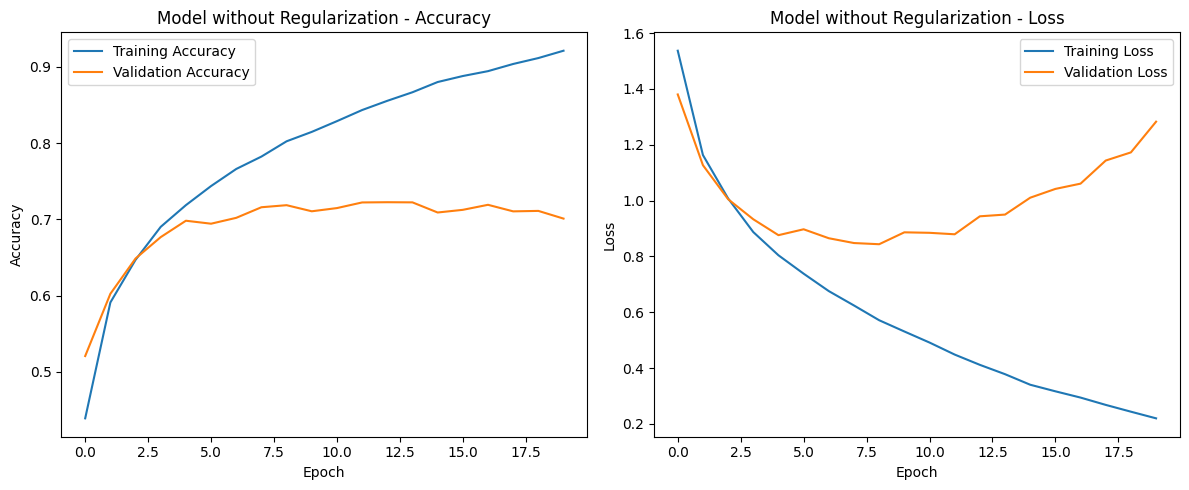


--- Model with Dropout Only ---


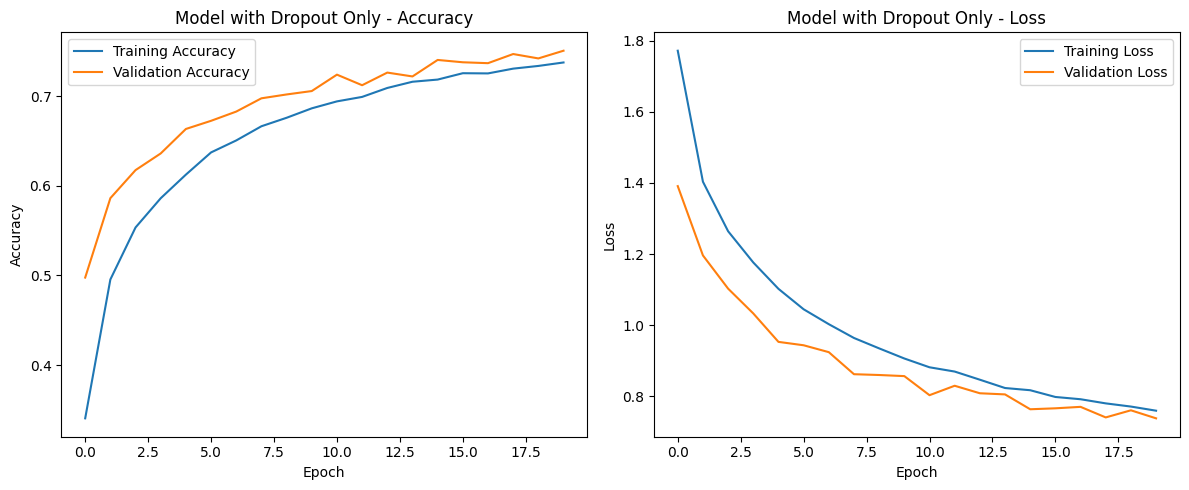


--- Model with L2 Regularization Only ---


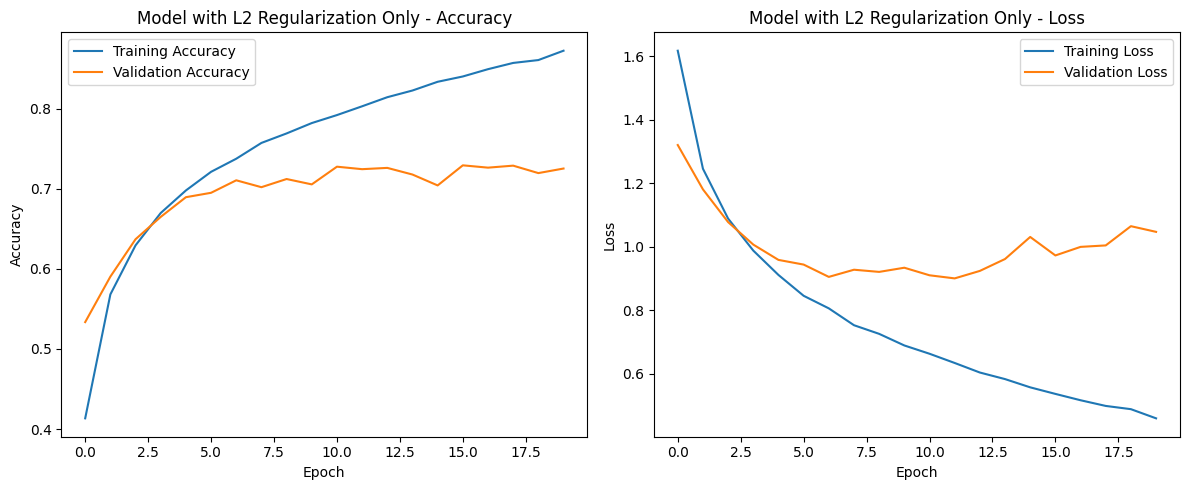


--- Model with Dropout + L2 + Early Stopping ---


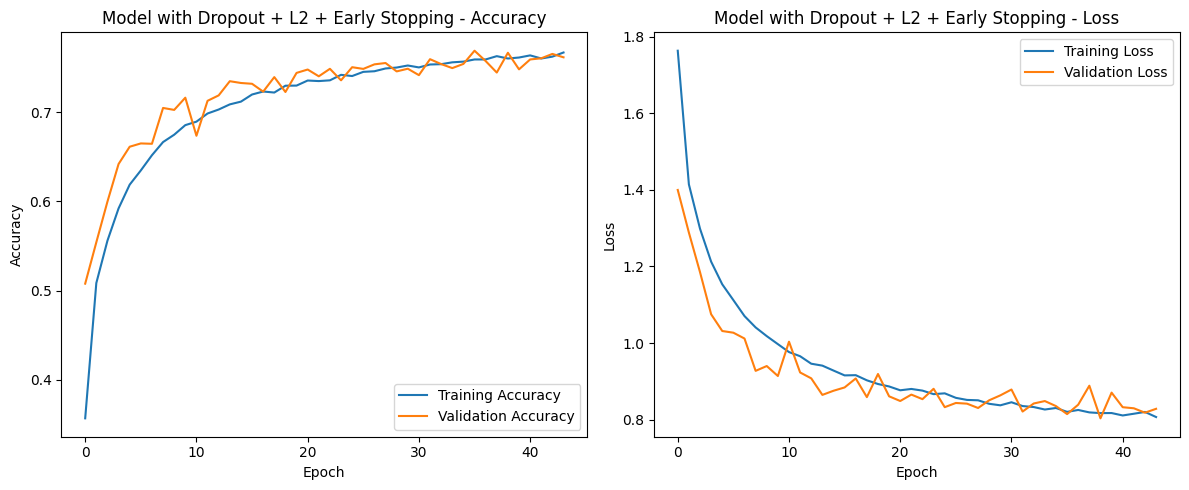

In [18]:
def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n--- Model without Regularization ---")
plot_history(history_no_reg, 'Model without Regularization')

print("\n--- Model with Dropout Only ---")
plot_history(history_dropout, 'Model with Dropout Only')

print("\n--- Model with L2 Regularization Only ---")
plot_history(history_l2, 'Model with L2 Regularization Only')

print("\n--- Model with Dropout + L2 + Early Stopping ---")
plot_history(history_all_reg, 'Model with Dropout + L2 + Early Stopping')

In [19]:
results = pd.DataFrame({
    'Model': [
        'No Regularization',
        'Dropout Only',
        'L2 Regularization Only',
        'Dropout + L2 + Early Stopping'
    ],
    'Test Loss': [
        loss_no_reg,
        loss_dropout,
        loss_l2,
        loss_all_reg
    ],
    'Test Accuracy': [
        accuracy_no_reg,
        accuracy_dropout,
        accuracy_l2,
        accuracy_all_reg
    ]
})

print("\n--- Comparison of Model Performance ---")
display(results)


--- Comparison of Model Performance ---


,Model,Test Loss,Test Accuracy
0,No Regularization,1.282637,0.7010
1,Dropout Only,0.737798,0.7507
2,L2 Regularization Only,1.047115,0.7253
3,Dropout + L2 + Early Stopping,0.803549,0.7667


### Summary and Conclusion

Based on the visualizations and the comparison table above, we can analyze the impact of different regularization techniques on the CNN models trained on the CIFAR-10 dataset.

**Observed Performance (from `results` DataFrame):**

*   **No Regularization:**
    *   Test Loss: **1.2826**
    *   Test Accuracy: **0.7010**
    *   As expected, this model shows signs of overfitting with the highest loss and lowest accuracy among the models after training for 20 epochs.

*   **Dropout Only:**
    *   Test Loss: **0.7378**
    *   Test Accuracy: **0.7507**
    *   Introducing Dropout significantly improved performance, reducing the test loss and increasing accuracy compared to the no-regularization model. This indicates better generalization.

*   **L2 Regularization Only:**
    *   Test Loss: **1.0471**
    *   Test Accuracy: **0.7253**
    *   L2 regularization also helped in reducing overfitting compared to the baseline, resulting in lower loss and higher accuracy, though not as pronounced as Dropout in this case.

*   **Dropout + L2 + Early Stopping:**
    *   Test Loss: **0.8035**
    *   Test Accuracy: **0.7667**
    *   The combination of Dropout, L2 regularization, and Early Stopping yielded the best performance in terms of test accuracy. While its test loss is slightly higher than 'Dropout Only', the Early Stopping mechanism ensured that the model stopped training at its optimal generalization point, preventing further overfitting.

**Key Takeaways:**

*   Regularization techniques are crucial for improving the generalization ability of CNNs, especially on complex datasets like CIFAR-10.
*   Combining multiple regularization methods (e.g., Dropout, L2, Early Stopping) often yields superior results compared to using a single technique. In this specific scenario, the combined approach achieved the highest test accuracy of **0.7667**.
*   The choice and tuning of regularization parameters (e.g., dropout rate, L2 lambda) are important for optimal performance.